water 5
pigs 5
59056
munin 5
250000


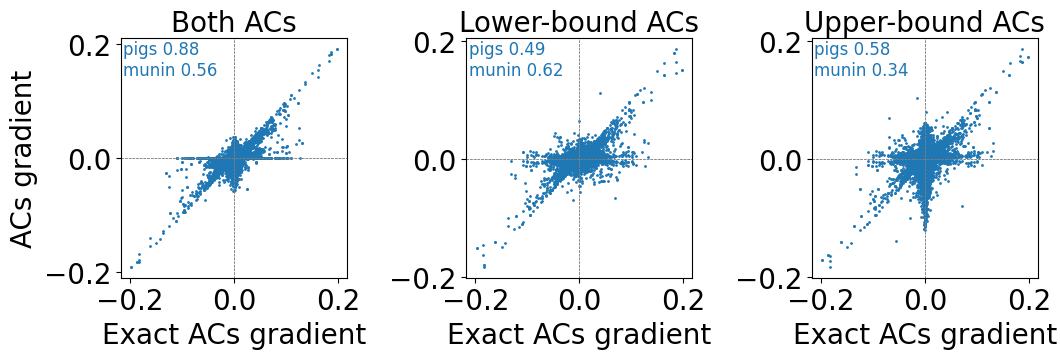

In [ ]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colorbar
import matplotlib.colors
import matplotlib.cm
import math
np.random.seed(0)

def add_headers(
    fig,
    *,
    row_headers=None,
    col_headers=None,
    row_pad=1,
    col_pad=5,
    rotate_row_headers=True,
    **text_kwargs
):
    # Based on https://stackoverflow.com/a/25814386

    axes = fig.get_axes()

    for ax in axes:
        sbs = ax.get_subplotspec()

        # Putting headers on cols
        if (col_headers is not None) and sbs.is_first_row():
            ax.annotate(
                col_headers[sbs.colspan.start],
                xy=(0.5, 1),
                xytext=(0, col_pad),
                xycoords="axes fraction",
                textcoords="offset points",
                ha="center",
                va="baseline",
                **text_kwargs,
            )

        # Putting headers on rows
        if (row_headers is not None) and sbs.is_first_col():
            ax.annotate(
                row_headers[sbs.rowspan.start],
                xy=(0, 0.5),
                xytext=(-ax.yaxis.labelpad - row_pad, 0),
                xycoords=ax.yaxis.label,
                textcoords="offset points",
                ha="right",
                va="center",
                rotation=rotate_row_headers * 90,
                **text_kwargs,
            )

folder = '/experiments/data/outputs_LDS/bayesian_networks/'
datasets = ['water', 'pigs', 'munin']
timeout = [5]

col_headers = ['Both ACs', 'Lower-bound ACs', 'Upper-bound ACs']
row_headers = None 



fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for i,t in enumerate(timeout):
    all_both = np.array([])
    all_exact_b = np.array([])
    all_model = np.array([])
    all_exact_m = np.array([])
    all_nonmodel = np.array([])
    all_exact_n = np.array([])
    corr_both_txt = ""
    corr_model_txt = ""
    corr_nonmodel_txt = ""
    for dataset in datasets:
        folder_both = folder + dataset +'/grad_e0_comparison_both/t'+str(t)+'/'
        folder_models = folder + dataset +'/grad_e0_comparison_models/t'+str(t)+'/'
        folder_nonmodels = folder + dataset +'/grad_e0_comparison_nonmodels/t'+str(t)+'/'
        both_approx = []
        both_exact = []
        model_approx = []
        model_exact = []
        nonmodel_approx = []
        nonmodel_exact = []
        for f in sorted(os.listdir(folder_both)):
            df = pd.read_csv(folder_both + f)
            e_g = np.array([float(v) for v in df['grad_exact'][0].split()])
            l_p = float(df['pred_l'][0])
            u_p = 1-float(df['pred_u'][0])
            l_g = np.array([float(v) for v in df['grad_l'][0].split()])
            u_g = np.array([float(v) for v in df['grad_u'][0].split()])
            
            df_models = pd.read_csv(folder_models + f)
            e_g_m = np.array([float(v) for v in df_models['grad_exact'][0].split()])
            a_g_m = np.array([float(v) for v in df_models['grad'][0].split()])
            
            df_nonmodels = pd.read_csv(folder_nonmodels + f)
            e_g_n = np.array([float(v) for v in df_nonmodels['grad_exact'][0].split()])
            a_g_n = np.array([float(v) for v in df_nonmodels['grad'][0].split()])
            if u_p-l_p < 0.0001: continue
            both_approx.append((l_g+u_g)/2)
            all_both = np.hstack((all_both, (l_g+u_g)/2))
            both_exact.append(e_g)
            all_exact_b = np.hstack((all_exact_b, e_g))
            model_approx.append(a_g_m)
            all_model = np.hstack((all_model, a_g_m))
            model_exact.append(e_g_m)
            all_exact_m = np.hstack((all_exact_m, e_g_m))
            nonmodel_approx.append(a_g_n)
            all_nonmodel = np.hstack((all_nonmodel, a_g_n))
            nonmodel_exact.append(e_g_n)
            all_exact_n = np.hstack((all_exact_n, e_g_n))
        both_approx = np.array(both_approx).flatten()
        both_exact = np.array(both_exact).flatten()
        model_approx = np.array(model_approx).flatten()
        model_exact = np.array(model_exact).flatten()
        nonmodel_approx = np.array(nonmodel_approx).flatten()
        nonmodel_exact = np.array(nonmodel_exact).flatten()
        if len(both_approx) == 0 or len(model_approx) == 0 or len(nonmodel_approx)==0: continue
        lim = min(len(both_approx), 250000)
        print(lim)
        indices_b = np.random.choice(len(both_exact), len(both_exact), replace=False)
        indices_m = np.random.choice(len(model_exact), len(model_exact), replace=False)
        indices_n = np.random.choice(len(nonmodel_exact), len(nonmodel_exact), replace=False)
        
        both_approx = both_approx[indices_b]
        both_exact = both_exact[indices_b]
        model_approx = model_approx[indices_m]
        model_exact = model_exact[indices_m]
        nonmodel_approx = nonmodel_approx[indices_n]
        nonmodel_exact = nonmodel_exact[indices_n]
        
        axes[0].scatter(both_exact, both_approx, s=1, color='tab:blue')
        axes[0].axhline(0, color='gray', lw=0.5, linestyle='--')
        axes[0].axvline(0, color='gray', lw=0.5, linestyle='--')
        axes[0].set_xlabel('Exact ACs gradient')
        axes[0].set_ylabel('ACs gradient')
        
        axes[1].scatter(model_exact, model_approx, s=1, color='tab:blue')
        axes[1].axhline(0, color='gray', lw=0.5, linestyle='--')
        axes[1].axvline(0, color='gray', lw=0.5, linestyle='--')
        axes[1].set_xlabel('Exact ACs gradient')
        
        axes[2].set_xlabel('Exact ACs gradient')
        axes[2].scatter(nonmodel_exact, nonmodel_approx, s=1, color='tab:blue')
        axes[2].axhline(0, color='gray', lw=0.5, linestyle='--')
        axes[2].axvline(0, color='gray', lw=0.5, linestyle='--')
        
        corr_both = np.corrcoef(np.array(all_exact_b).flatten(), np.array(all_both).flatten())[0][1]
        corr_model = np.corrcoef(np.array(all_exact_m).flatten(), np.array(all_model).flatten())[0][1]
        corr_nonmodel = np.corrcoef(np.array(all_exact_n).flatten(), np.array(all_nonmodel).flatten())[0][1]
        corr_both_txt += dataset + ' ' + "{:.2}".format(corr_both) + '\n'
        corr_model_txt += dataset + ' ' + "{:.2}".format(corr_model) + '\n'
        corr_nonmodel_txt += dataset + ' ' + "{:.2}".format(corr_nonmodel) + '\n'
    axes[0].text(.01, .99, corr_both_txt, ha='left', va='top', transform=axes[0].transAxes, fontsize=12, color='tab:blue')
    axes[1].text(.01, .99, corr_model_txt, ha='left', va='top', transform=axes[1].transAxes, fontsize=12, color='tab:blue')
    axes[2].text(.01, .99, corr_nonmodel_txt, ha='left', va='top', transform=axes[2].transAxes, fontsize=12, color='tab:blue')

#plt.show()
add_headers(fig, row_headers=row_headers, col_headers=col_headers)
plt.rcParams.update({'font.size': 20})
fig.tight_layout()
plt.savefig('grad_epoch0_3_mini.png')

